In [1]:

from pathlib import Path

# neural_transport
from neural_transport.models.wrappers_registry import MODELWRAPPERS
from neural_transport.litmodule import NeuralTransport
from neural_transport.tools.conversion import *
from neural_transport.datasets.grids import (
    LATLON_PROTOTYPE_COORDS,
    VERTICAL_LAYERS_PROTOTYPE_COORDS,
)
from neural_transport.datamodule import CarbonDataModule

# plotting
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib import cm

# numpy
import numpy as np

# torch
import pytorch_lightning as pl
import torch
import torch.nn as nn
import torch_harmonics

import xarray as xr

# flow_matching
from flow_matching.path.scheduler import CondOTScheduler
from flow_matching.path import AffineProbPath
from flow_matching.solver import ODESolver


/Net/Groups/BGI/work_5/scratch/jgross/neuraltransport/lib/python3.12/site-packages/torch_geometric/typing.py:68: UserWarning: An issue occurred while importing 'pyg-lib'. Disabling its usage. Stacktrace: /lib64/libm.so.6: version `GLIBC_2.29' not found (required by /Net/Groups/BGI/work_5/scratch/jgross/neuraltransport/lib/python3.12/site-packages/libpyg.so)
  warnings.warn(f"An issue occurred while importing 'pyg-lib'. "
/Net/Groups/BGI/work_5/scratch/jgross/neuraltransport/lib/python3.12/site-packages/torch_geometric/typing.py:86: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: /lib64/libc.so.6: version `GLIBC_2.32' not found (required by /Net/Groups/BGI/work_5/scratch/jgross/neuraltransport/lib/python3.12/site-packages/torch_scatter/_version_cuda.so)
  warnings.warn(f"An issue occurred while importing 'torch-scatter'. "
/Net/Groups/BGI/work_5/scratch/jgross/neuraltransport/lib/python3.12/site-packages/torch_geometric/typing.py:97: User

In [2]:
torch.set_float32_matmul_precision("high")
pl.seed_everything(42)

Seed set to 42


42

In [3]:
TARGET_VARS = ["co2massmix"]
# Uncomment for conditional Flow Matching
FORCING_VARS_1D = [
    # "flow_time"
]
FORCING_VARS_2D = [
    # "blh",
    # "cell_area",
    # "co2flux_anthro",
    # "co2flux_land",
    # "co2flux_ocean",
    # "orography",
    # "tisr",
]
FORCING_VARS_3D = [
    # "airmass",
    # "gph_bottom",
    # "gph_top",
    # "p_bottom",
    # "p_top",
    # "q",
    # "t",
    # "u",
    # "v",
]
grid = "latlon5.625"
vertical_levels = "l10"
freq = "6h"

nlev = len(VERTICAL_LAYERS_PROTOTYPE_COORDS[vertical_levels]["level"])

FORCING_VARS = FORCING_VARS_1D + FORCING_VARS_2D + FORCING_VARS_3D
LEN_ALL_TARGET_VARS = nlev * len(TARGET_VARS)
LEN_ALL_FORCING_VARS = len(FORCING_VARS_1D) + len(FORCING_VARS_2D) + nlev * len(FORCING_VARS_3D)
LEN_ALL_VARS = LEN_ALL_TARGET_VARS + LEN_ALL_FORCING_VARS

lat = LATLON_PROTOTYPE_COORDS[grid]["lat"]
lon = LATLON_PROTOTYPE_COORDS[grid]["lon"]

cos_lat = np.cos(np.radians(lat))[:, None, None].repeat(len(lon), axis=1).reshape(-1, 1)
cos_lat = cos_lat / np.mean(cos_lat)

ds_stats = xr.open_zarr(
    f"/Net/Groups/BGI/tscratch/vbenson/graph_tm/data/Carbontracker/train/carbontracker_{grid}_{vertical_levels}_{freq}_stats.zarr"
).compute()

inv_std = {
    k: 1
    / (ds_stats[f"{k}_delta"].sel(stats="std").where(lambda x: x > 1e-14, 1).values)
    ** 2
    for k in TARGET_VARS  # CARBOSCOPE_CARBON3D_VARS
}

weights = {k: cos_lat * inv_std[k] for k in inv_std}

LOSS_WEIGHTS = {k: (10 * v / LEN_ALL_TARGET_VARS) for k, v in weights.items()}

METRIC_WEIGHTS = {f"{k}_delta": cos_lat for k in TARGET_VARS}


MODEL_DIMS = {
    "XS": dict(embed_dim=64),
    "S": dict(embed_dim=128),
    "M": dict(embed_dim=256),
    "L": dict(embed_dim=512),
    "XL": dict(embed_dim=1024),
}

MODEL_SIZE = "S"

regulargrid_kwargs = dict( # for RegularGridModel
    input_vars=TARGET_VARS + FORCING_VARS,
    target_vars=TARGET_VARS,
    nlat=len(lat),
    nlon=len(lon),
    predict_delta=False,
    add_surfflux=False,
    dt=60 * 60 * 6,
    massfixer="",
    targshift=True,
)

wrapper_kwargs = dict( # for RegularGridModel (FlowMatching)
    **regulargrid_kwargs,
    model_kwargs=dict( # for FlowMatching
        submodel="unet",
        model_kwargs=dict( # for RegularGridModel (UNet)
            **regulargrid_kwargs,
            model_kwargs=dict( # for UNet
                in_chans=LEN_ALL_VARS + 1, # + 1 for flow_time
                out_chans=LEN_ALL_TARGET_VARS,
                embed_dim=MODEL_DIMS[MODEL_SIZE]["embed_dim"],
                act="leakyrelu",
                norm="batch",
                enc_filters=[[7], [3, 3], [3, 3], [3, 3]],
                dec_filters=[[3, 3], [3, 3], [3, 3], [3, 3]],
                in_interpolation="bilinear",
                out_interpolation="nearest-exact",
                out_clip=None,
            ),
        ),
        return_intermediates=True,
        method="midpoint",  # 'midpoint' or 'euler'
        nlev=nlev,
        step_size=0.1,
    ),
)

In [4]:
print(f"vertical layers prototype coords: {nlev}")
print(f"Lenth of 1D forcing variables: {len(FORCING_VARS_1D)}")
print(f"Lenght of 2D forcing variables: {len(FORCING_VARS_2D)}")
print(f"Length of 3D forcing variables: {len(FORCING_VARS_3D)}")
print(f"Length of all forcing variables: {len(FORCING_VARS_1D)} + {len(FORCING_VARS_2D)} + {nlev} * {len(FORCING_VARS_3D)} = {LEN_ALL_FORCING_VARS}")
print(f"Length of all target variables: {LEN_ALL_TARGET_VARS}")
print(f"Length of all variables: {LEN_ALL_VARS}")

print(f"Latitude: {regulargrid_kwargs['nlat']}, Longitude: {regulargrid_kwargs['nlon']}")

vertical layers prototype coords: 10
Lenth of 1D forcing variables: 0
Lenght of 2D forcing variables: 0
Length of 3D forcing variables: 0
Length of all forcing variables: 0 + 0 + 10 * 0 = 0
Length of all target variables: 10
Length of all variables: 10
Latitude: 32, Longitude: 64


In [5]:
# train UNet parameters 2/2

N_GPUS = 1
BATCH_SIZE_TRAIN = 64
BATCH_SIZE_PRED = 32

data_kwargs = dict(
    data_path="/Net/Groups/BGI/tscratch/vbenson/graph_tm/data/Carbontracker",
    dataset="carbontracker",
    grid=grid,
    vertical_levels=vertical_levels,
    freq=freq,
    n_timesteps=1,
    batch_size_train=BATCH_SIZE_TRAIN // N_GPUS,
    batch_size_pred=BATCH_SIZE_PRED,
    num_workers=32 * N_GPUS,
    val_rollout_n_timesteps=None,
    target_vars=["co2massmix"], #, "airmass"
    forcing_vars=[
        # "gph_bottom",
        # "gph_top",
        # "p_bottom",
        # "p_top",
        # "q",
        # "t",
        # "u",
        # "v",
        # "blh",
        # "cell_area",
        # "co2flux_anthro",
        # "co2flux_land",
        # "co2flux_ocean",
        # "orography",
        # "tisr",
    ],
    compute=False,
)

In [6]:
# Load batch from dataset

dset = CarbonDataModule(**data_kwargs)
dset.setup('fit')
dset.val_dataset
dl = dset.train_dataloader()
print(type(dl))
print(len(dl))
batch = next(iter(dl))
batch = {k: v[:, 0,...] if isinstance(v, torch.Tensor) else v for k, v in batch.items() }
print(batch.keys())
print(len(batch))

<class 'torch.utils.data.dataloader.DataLoader'>
388
dict_keys(['airmass_delta_offset', 'airmass_delta_scale', 'airmass_next_offset', 'airmass_next_scale', 'airmass_offset', 'airmass_scale', 'blh_delta_offset', 'blh_delta_scale', 'blh_next_offset', 'blh_next_scale', 'blh_offset', 'blh_scale', 'cell_area_delta_offset', 'cell_area_delta_scale', 'cell_area_next_offset', 'cell_area_next_scale', 'cell_area_offset', 'cell_area_scale', 'co2flux_anthro_delta_offset', 'co2flux_anthro_delta_scale', 'co2flux_anthro_next_offset', 'co2flux_anthro_next_scale', 'co2flux_anthro_offset', 'co2flux_anthro_scale', 'co2flux_land_delta_offset', 'co2flux_land_delta_scale', 'co2flux_land_next_offset', 'co2flux_land_next_scale', 'co2flux_land_offset', 'co2flux_land_scale', 'co2flux_ocean_delta_offset', 'co2flux_ocean_delta_scale', 'co2flux_ocean_next_offset', 'co2flux_ocean_next_scale', 'co2flux_ocean_offset', 'co2flux_ocean_scale', 'co2massmix', 'co2massmix_delta_offset', 'co2massmix_delta_scale', 'co2massmix

In [7]:
flow = MODELWRAPPERS["flowmatching"](**wrapper_kwargs)

flow.n_samples = 10

In [8]:
# lit_module_kwargs

lit_module_kwargs = dict(
    model=flow,
    model_kwargs=wrapper_kwargs["model_kwargs"],
    loss="flowmatching_mse",
    loss_kwargs=dict(),
    metrics=[
        dict(name=m, kwargs=dict(weights=METRIC_WEIGHTS))
        for m in ["rmse", "r2", "nse", "rabsbias", "rrmse"]
    ],
    # + [dict(name="mass_rmsev2", kwargs=dict(molecule=m)) for m in ["co2"]],
    no_grad_step_shedule=None,
    lr=1e-3,
    weight_decay=0.1,
    lr_shedule_kwargs=dict(
        warmup_steps=1000, halfcosine_steps=99000, min_lr=3e-7, max_lr=1.0
    ),
    val_dataloader_names=["singlestep"],
    plot_kwargs=dict(
        variables=["co2molemix"],
        layer_idxs=[0, 3, 5, 8],
        n_samples=2,
        dataset="carbontracker",
        grid=grid,
        vertical_levels=vertical_levels,
        max_workers=32,
    ),
)

In [9]:
# trainer_kwargs

data_path_forecast = Path(
    "/Net/Groups/BGI/tscratch/vbenson/graph_tm/data/Carbontracker/test/"
)

trainer_kwargs = dict(
    max_steps=10000,
    accelerator="gpu",
    devices=N_GPUS,
    log_every_n_steps=100,
    gradient_clip_val=32,
    precision="bf16-mixed",
    strategy=(
        "auto"
        if N_GPUS == 1
        else pl.strategies.DDPStrategy(find_unused_parameters=False)
    ), # profiler="simple", fast_dev_run=True,
    # overfit_batches=10, # for debugging only!!
)

In [10]:
litmodule = NeuralTransport(
    model=flow,
    model_kwargs=wrapper_kwargs["model_kwargs"],
    loss="flowmatching_mse",
    loss_kwargs=dict(),
    metrics=[dict(name="rmse", kwargs=dict(weights=METRIC_WEIGHTS))],
)

In [12]:
# outputs = litmodule(batch)
# loss, losses = litmodule.loss(outputs, batch)
# print(f"Loss: {loss.item():.6f}")

# Plot results after training completed

1. Load model from best checkpoint
2. prepare batch of input data
3. run inference mode of model
4. plot results

In [13]:
# checkpoint path

# best
best_ckpt_path = "/Net/Groups/BGI/work_5/CO2_diffusion/carbonbench/transport_models/carbontracker_lowres/flowmatching_dev/flowmatching_20250916_dev/singlestep/checkpoints/best.ckpt"

# last
last_ckpt_path = "/Net/Groups/BGI/work_5/CO2_diffusion/carbonbench/transport_models/carbontracker_lowres/flowmatching_dev/flowmatching_20250916_dev/singlestep/checkpoints/last.ckpt"

In [14]:
# lit module kwargs

cos_lat = np.cos(np.radians(lat))[:, None, None].repeat(len(lon), axis=1).reshape(-1, 1)
cos_lat = cos_lat / np.mean(cos_lat)

ds_stats = xr.open_zarr(
    f"/Net/Groups/BGI/tscratch/vbenson/graph_tm/data/Carbontracker/train/carbontracker_{grid}_{vertical_levels}_{freq}_stats.zarr"
).compute()

inv_std = {
    k: 1
    / (ds_stats[f"{k}_delta"].sel(stats="std").where(lambda x: x > 1e-14, 1).values)
    ** 2
    for k in TARGET_VARS  # CARBOSCOPE_CARBON3D_VARS
}

weights = {k: cos_lat * inv_std[k] for k in inv_std}

LOSS_WEIGHTS = {k: (10 * v / LEN_ALL_TARGET_VARS) for k, v in weights.items()}

METRIC_WEIGHTS = {f"{k}_delta": cos_lat for k in TARGET_VARS}


lit_module_kwargs = dict(
    model=flow,
    model_kwargs=wrapper_kwargs["model_kwargs"],
    loss="flowmatching_mse",
    loss_kwargs=dict(),
    metrics=[
        dict(name=m, kwargs=dict(weights=METRIC_WEIGHTS))
        for m in ["rmse", "r2", "nse", "rabsbias", "rrmse"]
    ],
    # + [dict(name="mass_rmsev2", kwargs=dict(molecule=m)) for m in ["co2"]],
    no_grad_step_shedule=None,
    lr=1e-3,
    weight_decay=0.1,
    lr_shedule_kwargs=dict(
        warmup_steps=1000, halfcosine_steps=99000, min_lr=3e-7, max_lr=1.0
    ),
    val_dataloader_names=["singlestep", "rollout"],
    plot_kwargs=dict(
        variables=["co2molemix"],
        layer_idxs=[0, 3, 5, 8],
        n_samples=2,
        dataset="carbontracker",
        grid=grid,
        vertical_levels=vertical_levels,
        max_workers=32,
    ),
)

In [15]:
transport_model = NeuralTransport.load_from_checkpoint(last_ckpt_path, map_location="cpu")
transport_model.eval()

NeuralTransport(
  (model): FlowMatching(
    (submodel): UNet(
      (enc_stages): ModuleList(
        (0): Sequential(
          (0): ResBlock(
            (pad): PeriodicPadding()
            (conv): Conv2d(11, 128, kernel_size=(7, 7), stride=(1, 1), bias=False)
            (act): LeakyReLU(negative_slope=0.01)
            (norm): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          )
        )
        (1-3): 3 x Sequential(
          (0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
          (1): ResBlock(
            (pad): PeriodicPadding()
            (conv): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), bias=False)
            (act): LeakyReLU(negative_slope=0.01)
            (norm): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          )
          (2): ResBlock(
            (pad): PeriodicPadding()
            (conv): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1

In [16]:
flow_model = transport_model.model

In [17]:
dl_val = dset.val_dataloader()
batch_val = next(iter(dl_val))
batch_val = {k: v.squeeze(1) if isinstance(v, torch.Tensor) else v for k, v in batch_val.items()}

In [18]:
with torch.no_grad():
    output = flow_model(batch_val)

In [19]:
for key in output:
    print(f"{key}: {output[key].shape}")

# print(output["trajectory"].shape) # [B=32, C=10, Nlat=32, Nlon=64, T=10]
print(batch_val["co2massmix"].shape) # [B=32, N=2048, C=10]
# print(output["co2massmix"].shape) # [B=32, N=2048, C=10]

co2massmix: torch.Size([32, 2048, 10])
trajectory: torch.Size([10, 32, 2048, 10])
torch.Size([32, 2048, 10])


In [20]:
target = batch_val["co2massmix"][0].cpu().numpy()
pred_trajectory = output["trajectory"][0].cpu().numpy() # [B N T]
pred = output["co2massmix"][0].cpu().numpy()

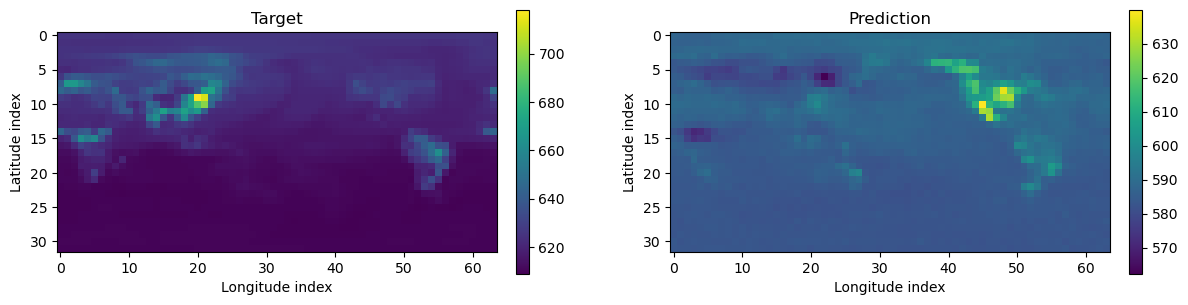

In [21]:
vlev = 0
nlat, nlon = 32, 64

target_2d = target[:, vlev].reshape(nlat, nlon)
pred_2d = pred[:, vlev].reshape(nlat, nlon)
pred_trajectory = pred_trajectory.reshape(nlev, nlat, nlon, -1)
pred_2d_trajectory = pred_trajectory[vlev, :, :, -1]

# vmin = min(target_2d.min(), pred_2d.min())
# vmax = max(target_2d.max(), pred_2d.max())

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot target
im0 = axes[0].imshow(target_2d[::-1], cmap="viridis") #, vmin=vmin, vmax=vmax
axes[0].set_title("Target")
axes[0].set_xlabel("Longitude index")
axes[0].set_ylabel("Latitude index")
fig.colorbar(im0, ax=axes[0], fraction=0.028, pad=0.04)

# Plot prediction
im1 = axes[1].imshow(pred_2d[::-1], cmap="viridis") #, vmin=vmin, vmax=vmax
axes[1].set_title("Prediction")
axes[1].set_xlabel("Longitude index")
axes[1].set_ylabel("Latitude index")
fig.colorbar(im1, ax=axes[1], fraction=0.028, pad=0.04)

# Adjust horizontal spacing between subplots
plt.subplots_adjust(wspace=0.3)

plt.savefig("flowmatching_target_prediction.png")
plt.show()


In [25]:
print("Target min/max:", target.min(), target.max())
print("Pred   min/max:", pred.min(), pred.max())
print("Traj.  min/max:", pred_2d_trajectory.min(), pred_2d_trajectory.max())

Target min/max: 595.88873 718.141
Pred   min/max: 562.29956 639.9541
Traj.  min/max: -3.5657773 3.2461789


torch.Size([10, 32, 64])


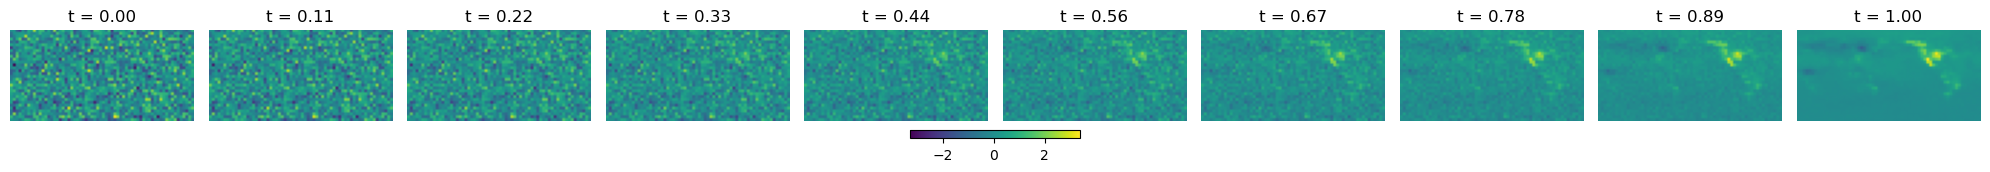

In [ ]:
# trajectory.shape: (T=10, B=32, N=2048, C=10) -> one batch (B=0), surface level (C=0)

trajectory = output["trajectory"]  # [T B N C]
T, B, N, C = trajectory.shape
trajectory = trajectory.reshape(T, B, nlat, nlon, C)
sol_surface = trajectory[:, 0, :, :, 0]  # shape: [T, Nlat, Nlon]
sol_surface_flipped = torch.flip(sol_surface, dims=[1])

# plot
fig, axs = plt.subplots(1, T, figsize=(20, 2))

vmin, vmax = sol_surface_flipped.min(), sol_surface_flipped.max()
for i in range(T):
    im = axs[i].imshow(sol_surface_flipped[i, :, :], cmap="viridis", vmin=vmin, vmax=vmax)
    axs[i].set_title(f"t = {i/9:.2f}")
    axs[i].axis("off")

plt.tight_layout()
plt.colorbar(im, ax=axs, orientation='horizontal', fraction=0.05, pad=0.05)

plt.savefig("flowmatching_trajectory.png")
plt.show()

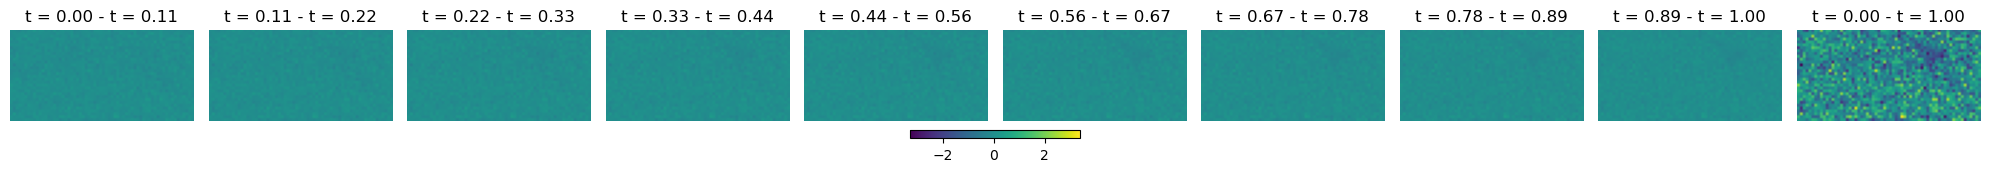

In [40]:
# Print differences between trajectory steps

# plot
fig, axs = plt.subplots(1, T, figsize=(20, 2))

for i in range(T-1):
    im = axs[i].imshow(sol_surface_flipped[i, :, :] - sol_surface_flipped[i+1, :, :], cmap="viridis", vmin=vmin, vmax=vmax)
    axs[i].set_title(f"t = {i/9:.2f} - t = { (i+1)/9:.2f}")
    axs[i].axis("off")

im = axs[T-1].imshow(sol_surface_flipped[0, :, :] - sol_surface_flipped[T-1, :, :], cmap="viridis", vmin=vmin, vmax=vmax)
axs[T-1].set_title(f"t = {0/9:.2f} - t = {9/9:.2f}")
axs[T-1].axis("off")

plt.tight_layout()
plt.colorbar(im, ax=axs, orientation='horizontal', fraction=0.05, pad=0.05)

plt.show()

In [ ]:
torch.round(sol_surface[0, :, :] - sol_surface[9, :, :], decimals=2)
# noise is changing over time!

tensor([[ 0.2900,  0.0900,  0.0100,  ..., -0.1800,  1.1200, -0.7000],
        [ 1.1800, -0.2300,  0.3200,  ..., -1.1300,  1.4100, -0.0300],
        [-0.6700,  2.2600, -0.8700,  ...,  1.2500, -0.2900, -0.3700],
        ...,
        [-1.1900, -0.6400,  0.1200,  ..., -0.0100,  1.7600,  0.0400],
        [-0.9500, -0.0100,  0.0500,  ..., -0.3800, -1.3500, -1.0000],
        [-0.1400, -0.0300, -1.6400,  ..., -1.5500, -0.6100,  0.8800]])

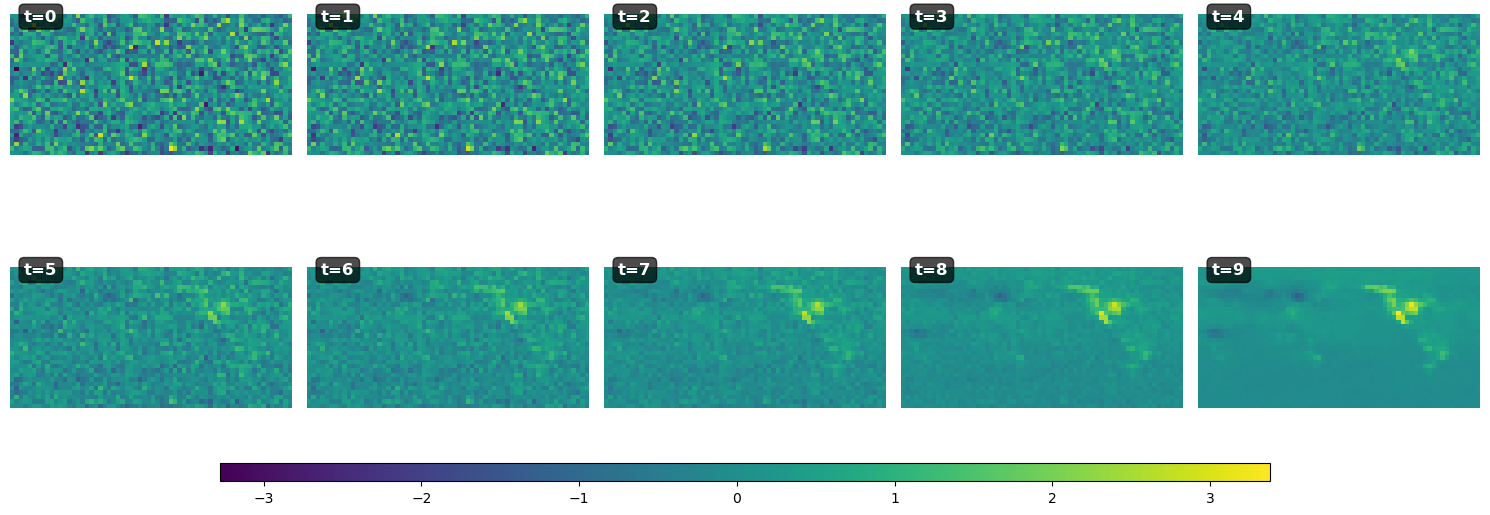

In [47]:
trajectory_vitus = output["trajectory"][:, 0, :, :].squeeze(1) # [T=10, N=2048, C=10]
trajectory_vitus = trajectory_vitus.view(trajectory_vitus.shape[0], nlat, nlon, trajectory_vitus.shape[-1]) # [T=10, Nlat=32, Nlon=64, C=10]
trajectory_vitus = trajectory_vitus.cpu().numpy()

# Plot a timeseries of maps of the trajectory for a given level
level_to_plot = 0  # Choose a level to plot
nsteps = trajectory_vitus.shape[0]

# Create a clean flow visualization with two rows
ncols = nsteps // 2 if nsteps % 2 == 0 else (nsteps + 1) // 2
nrows = 2 if nsteps > ncols else 1

fig, axes = plt.subplots(nrows, ncols, figsize=(3 * ncols, 3 * nrows))

# Handle different cases for axes indexing
if nrows == 1:
    if ncols == 1:
        axes = [axes]
    else:
        axes = axes.reshape(1, -1)
elif ncols == 1:
    axes = axes.reshape(-1, 1)

# Find global min/max for consistent colormap
vmin = trajectory_vitus[:, :, :, level_to_plot].min()
vmax = trajectory_vitus[:, :, :, level_to_plot].max()

for i in range(nsteps):
    row = i // ncols
    col = i % ncols

    if nrows == 1:
        ax = axes[col] if ncols > 1 else axes[0]
    else:
        ax = axes[row, col]

    im = ax.imshow(
        trajectory_vitus[i, :, :, level_to_plot],
        origin="lower",
        vmin=vmin,
        vmax=vmax,
        cmap="viridis",
    )

    # Remove all axis elements
    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_visible(False)
    ax.spines["left"].set_visible(False)

    # Optional: add step number as text overlay
    ax.text(
        0.05,
        0.95,
        f"t={i}",
        transform=ax.transAxes,
        fontsize=12,
        fontweight="bold",
        color="white",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="black", alpha=0.7),
    )

# Hide any unused subplots
if nsteps < nrows * ncols:
    for i in range(nsteps, nrows * ncols):
        row = i // ncols
        col = i % ncols
        if nrows == 1:
            axes[col].set_visible(False)
        else:
            axes[row, col].set_visible(False)

# Add horizontal colorbar below
plt.subplots_adjust(bottom=0.2)
cbar_ax = fig.add_axes([0.15, 0.05, 0.7, 0.03])
fig.colorbar(im, cax=cbar_ax, orientation="horizontal")

plt.tight_layout()
plt.show()

# Generative predictions

### Toy batches for testing

In [48]:
# print(f"keys of batch_val: {batch_val.keys()}")
# print(f"shape of batch_val['co2massmix']: {batch_val['co2massmix'].shape}") # [B=32, N=2048, C=10]
# print(f"length of batch_val: {len(batch_val)}")

# toy batch reduced to co2massmix only
toy_batch_co2massmix = {k: v.clone() for k, v in batch_val.items() if "co2massmix" in k}

nlat, nlon = 32, 64

# toy batch with values set to zero
toy_batch_zeros = {k: torch.zeros_like(v) for k, v in toy_batch_co2massmix.items()}

# toy batch with values set to 1
toy_batch_ones = {k: torch.ones_like(v) for k, v in toy_batch_co2massmix.items()}

# toy batch with values set to right and left
left = 0.0
right = 500.0
toy_batch_rl = {k: v.clone() for k, v in toy_batch_co2massmix.items()}

for k, v in toy_batch_rl.items():
    if "scale" not in k and "offset" not in k:
        v_reshaped = v.clone().reshape(v.shape[0], nlat, nlon, v.shape[-1]) 
        v_reshaped[:, :, :nlon//2, :] = left
        v_reshaped[:, :, nlon//2:, :] = right
        toy_batch_rl[k] = v_reshaped.reshape(v.shape)
    elif "scale" in k:
        toy_batch_rl[k] = torch.ones_like(v) * 250.0
    elif "offset" in k:
        toy_batch_rl[k] = torch.ones_like(v) * 250.0

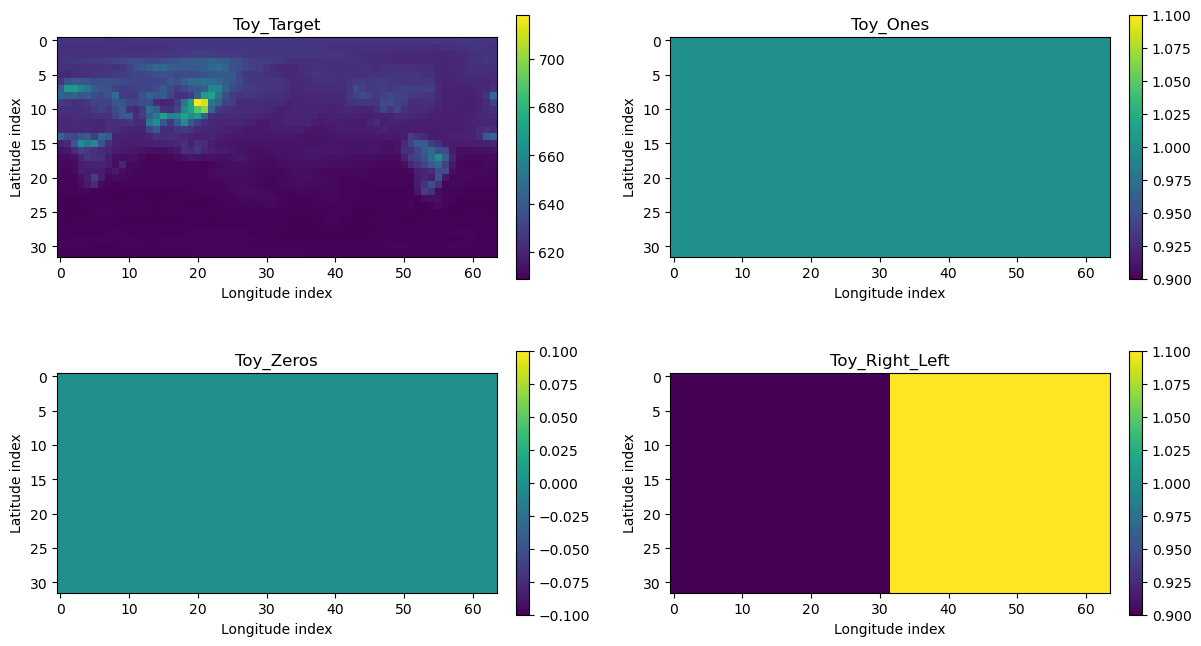

In [49]:
# Plot toy batches

vlev = 0
nlat, nlon = 32, 64

toy_co2massmix = toy_batch_co2massmix["co2massmix"][0].cpu().numpy()
toy_target_2d = toy_co2massmix[:, vlev].reshape(nlat, nlon)
toy_zeros = toy_batch_zeros["co2massmix"][0].cpu().numpy()
toy_zeros_2d = toy_zeros[:, vlev].reshape(nlat, nlon)
toy_rl = toy_batch_rl["co2massmix"][0].cpu().numpy()
toy_rl_2d = toy_rl[:, vlev].reshape(nlat, nlon)

# vmin = min(target_2d.min(), pred_2d.min())
# vmax = max(target_2d.max(), pred_2d.max())

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Plot toy batch co2massmix
im0 = axes[0][0].imshow(toy_target_2d[::-1], cmap="viridis") #, vmin=vmin, vmax=vmax
axes[0][0].set_title("Toy_Target")
axes[0][0].set_xlabel("Longitude index")
axes[0][0].set_ylabel("Latitude index")
fig.colorbar(im0, ax=axes[0][0], fraction=0.028, pad=0.04)

# Plot toy batch zeros
im1 = axes[1][0].imshow(toy_zeros_2d[::-1], cmap="viridis") #, vmin=vmin, vmax=vmax
axes[1][0].set_title("Toy_Zeros")
axes[1][0].set_xlabel("Longitude index")
axes[1][0].set_ylabel("Latitude index")
fig.colorbar(im1, ax=axes[1][0], fraction=0.028, pad=0.04)

# Plot toy batch ones
im2 = axes[0][1].imshow(toy_zeros_2d[::-1] + 1, cmap="viridis") #, vmin=vmin, vmax=vmax
axes[0][1].set_title("Toy_Ones")
axes[0][1].set_xlabel("Longitude index")
axes[0][1].set_ylabel("Latitude index")
fig.colorbar(im2, ax=axes[0][1], fraction=0.028, pad=0.04)

# Plot toy batch right and left
im3 = axes[1][1].imshow(toy_rl_2d[::-1], cmap="viridis") #, vmin=vmin, vmax=vmax
axes[1][1].set_title("Toy_Right_Left")
axes[1][1].set_xlabel("Longitude index")
axes[1][1].set_ylabel("Latitude index")
fig.colorbar(im2, ax=axes[1][1], fraction=0.028, pad=0.04)

# Adjust horizontal spacing between subplots
plt.subplots_adjust(wspace=0.3)

plt.show()


In [50]:
with torch.no_grad():
    toy_output = flow_model(toy_batch_rl)

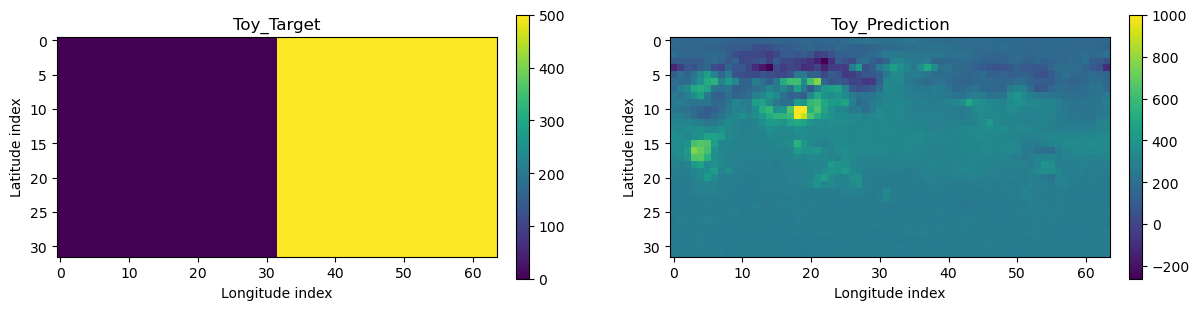

In [51]:
vlev = 0
nlat, nlon = 32, 64

toy_target = toy_batch_rl["co2massmix"][0].cpu().numpy()
toy_pred = toy_output["co2massmix"][0].cpu().numpy()
toy_target_2d = toy_target[:, vlev].reshape(nlat, nlon)
toy_pred_2d = toy_pred[:, vlev].reshape(nlat, nlon)

# vmin = min(target_2d.min(), pred_2d.min())
# vmax = max(target_2d.max(), pred_2d.max())

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot target
im0 = axes[0].imshow(toy_target_2d[::-1], cmap="viridis") #, vmin=vmin, vmax=vmax
axes[0].set_title("Toy_Target")
axes[0].set_xlabel("Longitude index")
axes[0].set_ylabel("Latitude index")
fig.colorbar(im0, ax=axes[0], fraction=0.028, pad=0.04)

# Plot prediction
im1 = axes[1].imshow(toy_pred_2d[::-1], cmap="viridis") #, vmin=vmin, vmax=vmax
axes[1].set_title("Toy_Prediction")
axes[1].set_xlabel("Longitude index")
axes[1].set_ylabel("Latitude index")
fig.colorbar(im1, ax=axes[1], fraction=0.028, pad=0.04)

# Adjust horizontal spacing between subplots
plt.subplots_adjust(wspace=0.3)

plt.show()


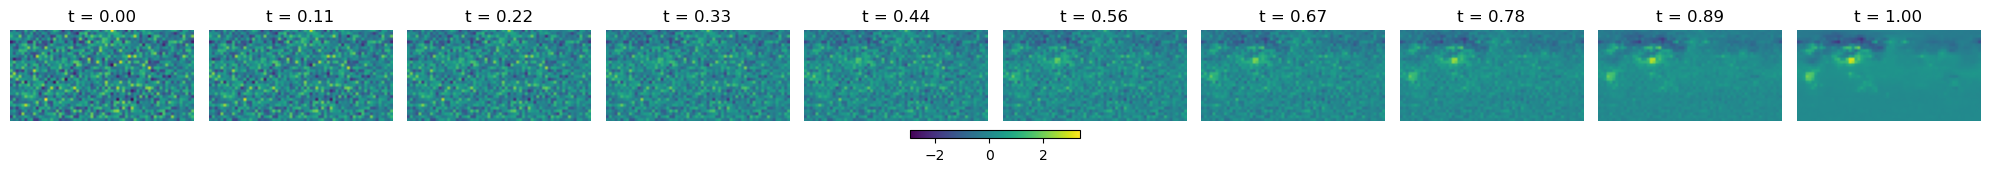

In [55]:
# trajectory.shape: (T=10, B=32, N=2048, C=10) -> one batch (B=0), surface level (C=0)

toy_trajectory = toy_output["trajectory"]  # [T B N C]
toy_sol_surface = toy_trajectory[:, 0, :, 0] # [T, N]
toy_sol_surface = toy_sol_surface.permute(1, 0) # [N, T]
toy_sol_surface = toy_sol_surface.reshape(nlat, nlon, -1) # [Nlat, Nlon, T]
toy_sol_surface = torch.flip(toy_sol_surface, dims=[0])

# plot
fig, axs = plt.subplots(1, 10, figsize=(20, 2))

vmin, vmax = toy_sol_surface.min(), toy_sol_surface.max()
for i in range(10):
    im = axs[i].imshow(toy_sol_surface[:, :, i], cmap="viridis", vmin=vmin, vmax=vmax)
    axs[i].set_title(f"t = {i/9:.2f}")
    axs[i].axis("off")

plt.tight_layout()
plt.colorbar(im, ax=axs, orientation='horizontal', fraction=0.05, pad=0.05)

plt.show()